# Post-processing chain

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [4]:
# Define paths used throughout
path = '/lhome/nicholas/software/workdir/mocka'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'

---
## Test poly-detrend model comparison
---

In [103]:
filename = f'{path}/simulations/tests/test_hdf5/000000001/000000001_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam4.1_Q3.hdf5'
lc = LightCurve(filename)

In [101]:
# Data
df = lc.data()
df = df.loc[:int(30*86400/25)]
df = df.rename(columns={'time':'x', 'flux':'y'})

# Test models
model1 = 'y ~ x'
model2 = 'y ~ x + I(x**2)'
model3 = 'y ~ x + I(x**2) + I(x**3)'
fit1 = sm.OLS.from_formula(formula=model1, data=df).fit()
fit2 = sm.OLS.from_formula(formula=model2, data=df).fit()
fit3 = sm.OLS.from_formula(formula=model3, data=df).fit()
# fit1.summary()

In [104]:
# # Show procedure of model comparison
# st.plot_modelfit(df, fit1, model1, theme='b')
# st.plot_modelfit(df, fit2, model2, theme='g')
# st.plot_modelfit(df, fit3, model3, theme='r')
# AIC_j = [fit1.aic, fit2.aic, fit3.aic]
# BIC_j = [fit1.bic, fit2.bic, fit3.bic]
# st.model_selection(AIC_j, BIC_j, method='BIC', show=True);

---
## Test post-processing steps (HDF5)
---

In [120]:
path0 = f'{path}/simulations/tests/test_hdf5'
#---------
filename = f'{path0}/000000001/000000001_Ncam1.1_Q1.hdf5'
#---------
# filename = f'{path0}/000003010/000003010_Ncam1.1_Q1.hdf5'
# filename = f'{path0}/000003010/000003010_Ncam1.1_Q2.hdf5'
#---------
lc = LightCurve(filename)
lc.star()

ID                           1
gaiaDR3    5303012479913170560
ra                  134.532937
dec                 -60.020178
mag                  15.316477
group                        1
camera                       1
quarter                      1
ccd                          2
xCCD               1851.767959
yCCD                800.446693
rOA                  17.148201
xFP                  -68.07196
yFP                 -34.631823
ncon                         3
SPR                   0.000211
Name: 0, dtype: object

<IPython.core.display.Javascript object>


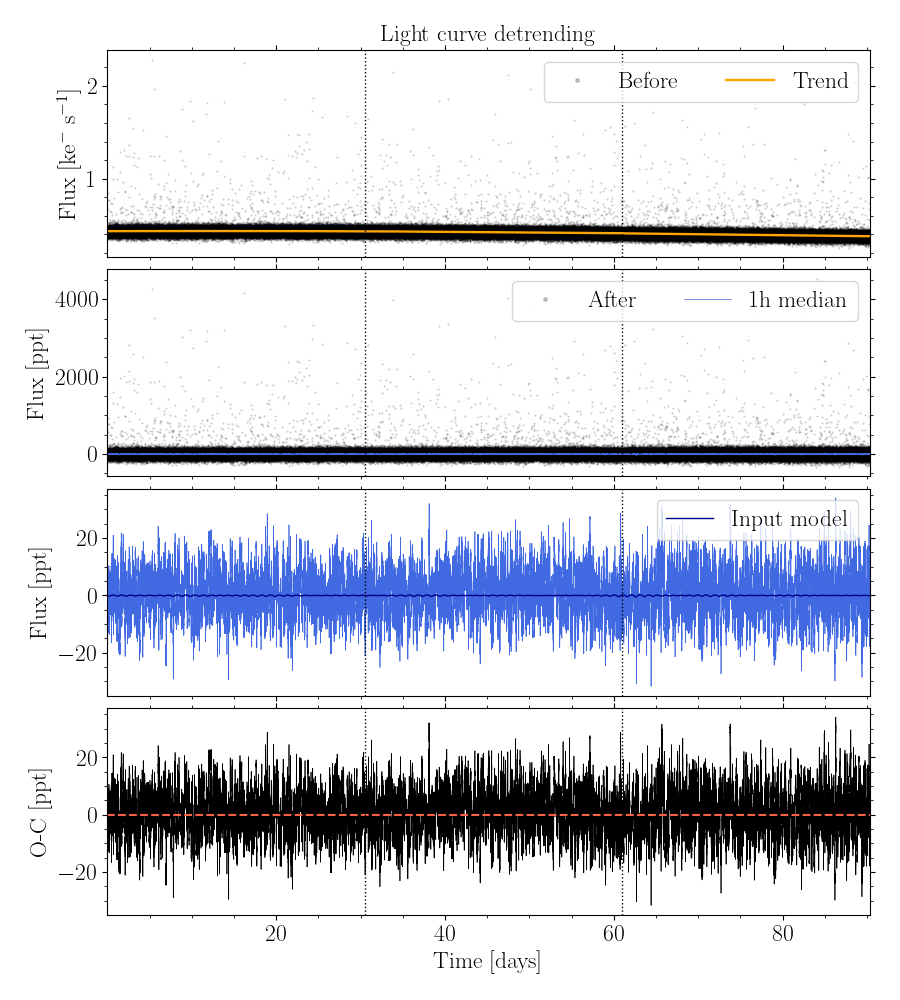

In [121]:
df = lc.detrend(model='poly', replace=True, plot=True)

<IPython.core.display.Javascript object>


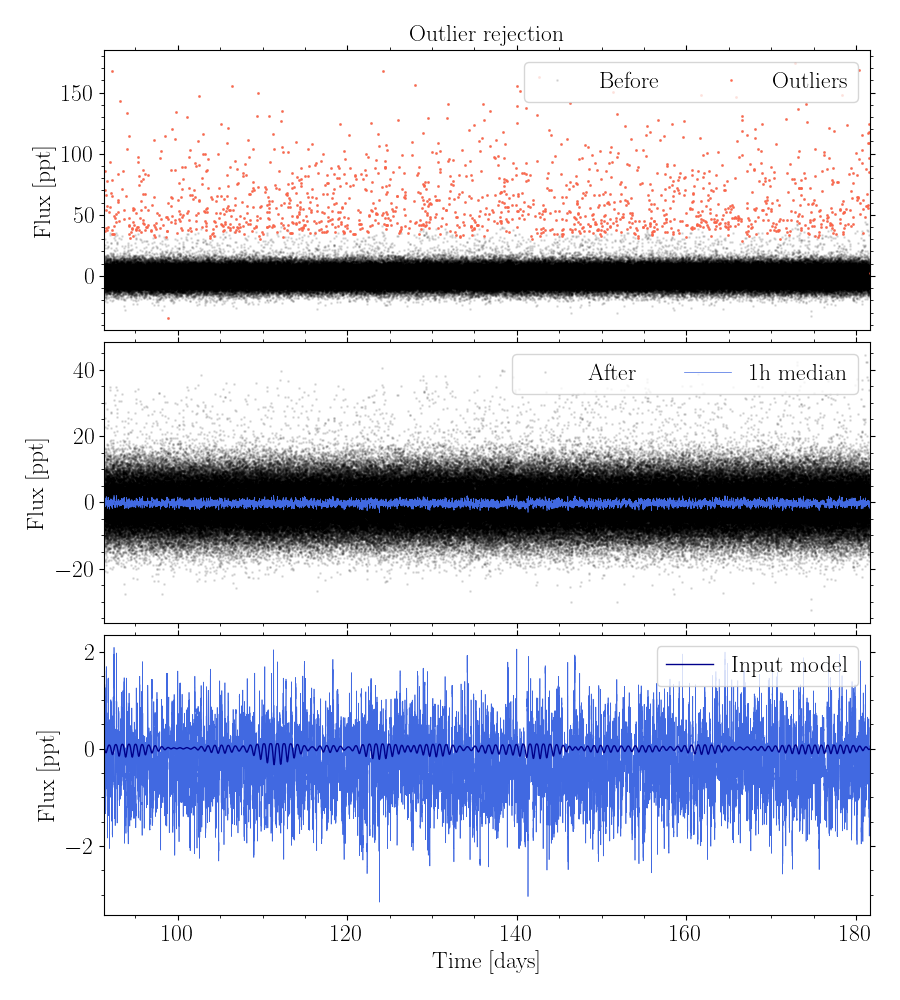

In [99]:
df = lc.clip(model='wotan', flux_unit='ppt', sigma_lower=4.5, sigma_upper=4.5, replace=True, plot=True)

In [418]:
df

,time,flux
0,6.25,1.004207
1,31.25,0.979733
2,56.25,1.017062
3,81.25,1.003974
4,106.25,1.001803
...,...,...
312108,7802706.25,1.007623
312109,7802731.25,1.001117
312110,7802756.25,0.991062
312111,7802781.25,0.996513


In [161]:
# lc.stitch(method='lowess', segment=30, replace=True, plot=True);

In [6]:
# sim = Simulation('test.hdf5') 
# beginExposureNr = int(315569*(int(filename[-6])-1))
# numExposures    = 312113

# # Transient correction
# inputFileCCD = f'{idir}/instrumentGTT.txt'
# dt = pd.read_csv(inputFileCCD, sep=' ', names=['time', 'temp'])
# dt = dt.iloc[beginExposureNr:beginExposureNr+numExposures]
# temp = dt.temp.to_numpy()
# inputFileGap = f'{idir}/instrumentGAP.tab'
# dg = pd.read_feather(inputFileGap)
# tdur = dg.td.iloc[0] / 86400
# tempNominal   = sim['CCD/NominalOperatingTemperature']
# gainCCD       = sim['CCD/Gain/RefValueRight']
# gainFEE       = sim['FEE/Gain/RefValueRight']
# gainStability = sim['FEE/Gain/Stability']
# df = lc.correct_gain(temp, tdur, tempNominal, gainCCD, gainFEE, gainStability, replace=True, plot=True)

---
## Test full reduction on HDF5
---

In [110]:
star = f'{1002}'.zfill(9)
idir = f'{path}/simulations/tests/test_hdf5/{star}'

# Load ligth curve object
lcs = LightCurve(idir, 'multi')

# Check sim info
N = len(lcs.files('hdf5')) / 8.
lc = LightCurve(lcs.files('hdf5')[0])

# Simulation table
ds = lc.star()

# Check max amplitude
dp = pd.read_feather(f'{path}/simulations/tests/varsource/{star}/varsource_001_parameters.ftr')

# dv = pd.read_csv(f'{path}/simulations/tests/varsource/{star}/varsource_001.txt', sep=' ', names=['time', 'dmag'])
# dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e3
# dv.time /= 86400

# Check predicted NSR camera and mission level
tdur = 3600
noise_jitter         = ut.getJitterNoiseLimitNSR(rms=0.037, tdur=tdur, level='camera')
noise_photon_camera  = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=1, tdur=tdur)
noise_photon_mission = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=N, tdur=tdur)
noise_background     = ut.getBackgroundNoiseLimitNSR(ds.mag, passband='P', tdur=tdur)
noise_camera  = noise_jitter + noise_photon_camera  + noise_background
noise_mission = noise_jitter + noise_photon_mission + noise_background

print(f'Max ampl    : {dp.Amax_mag[0] * 1.037e6:.0f} ppm')
print(f'NSR camera  : {noise_camera:.0f} ppm')
print(f'NSR mission : {noise_mission:.0f} ppm ({int(N)} N-CAM)')
ds

Max ampl    : 432 ppm
NSR camera  : 212 ppm
NSR mission : 95 ppm (12 N-CAM)


ID                        1002
gaiaDR3    5591274943754084352
ra                  112.800397
dec                 -34.932931
mag                  10.929007
group                        1
camera                       1
quarter                      1
ccd                          3
xCCD               3475.588591
yCCD               1925.992705
rOA                  17.864149
xFP                  63.860595
yFP                 -47.812131
ncon                         3
SPR                   0.025257
Name: 0, dtype: object

<IPython.core.display.Javascript object>


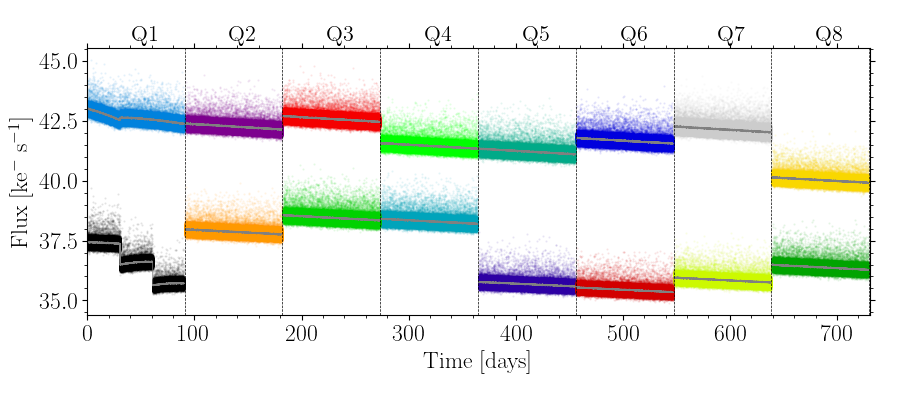

In [111]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=6, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,4))

In [112]:
lc = lcs.merge(suffix='hdf5', 
               verbose=True,
               detrend='poly',
               flux_group_mean=True, 
               clip=False, #df.mag.iloc[0], 
               binsize=0.2, 
               flux_offset=True, 
               flux_err=True, 
               ofile=f'{idir}/../lc_{star}.ftr')

Processing star ID 000001002
Merging light curves


100%|██████████████████████████████████████████████████| 96/96 [00:40<00:00,  2.


Sorting data after timings
Averaging data from same camera group
Binning data per 0.2h
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Done!


<IPython.core.display.Javascript object>


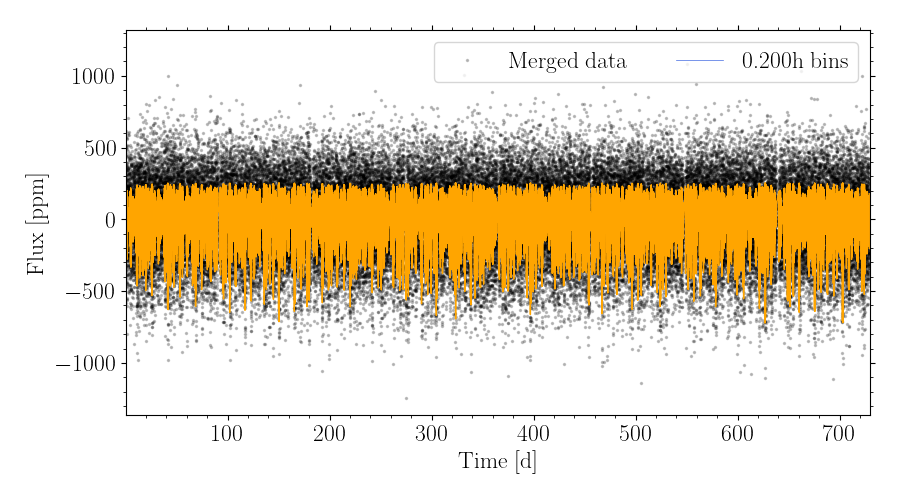

In [113]:
# Introduce data gaps
df = lc.gaps(f'{path}/input/instrumentGAP.tab', replace=True)
df = df.dropna()
df.time /= 86400

# Load variable template
dm = pd.read_feather(f'{path}/simulations/tests/varsource/{star}/varsource_001_pulsations.ftr')
dv = pd.DataFrame()
dv['time'] = df.time
dv['dmag'] = ns.timeSeriesFromFourier(df.time, dm.freq, dm.ampl, dm.phase, power=2.2)
dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e6

# Plot final light curve
fig, ax = lc.plot(flux_unit='ppm', median_filter=0.2)
ax.plot(dv.time, dv.flux, '-', c='orange', lw=1);

In [114]:
# Compute the residuals
df['flux_res'] = (df.flux - 1)*1e6 - dv.flux

# Compute NSR for star
NSR_res = np.std(df.flux_res)
RMS_res = ut.medianAbsoluteDeviation(df.flux_res)

# NSR from old function
dx = df.copy()
dx.time *= 86400
lc = LightCurve(dx, 'multi')
NSR = lc.getNSR(column='flux_res', influx='ppm', unit='ppm', binhour=1)

print('NSR measure per 600s')
print(f'Max ampl    : {dp.Amax_mag[0] * 1.037e6:.0f} ppm')
print(f'NSR camera  : {noise_camera:.0f} ppm')
print(f'NSR mission : {noise_mission:.0f} ppm ({N} Ncam)')
print('-------------')
print(f'NSR method  : {NSR:.0f} ppm in 1h')
print(f'NSR measure : {NSR_res:.0f} ppm ({N} Ncam)')
print(f'RMS measure : {RMS_res:.0f} ppm ({N} Ncam)')

NSR measure per 600s
Max ampl    : 432 ppm
NSR camera  : 212 ppm
NSR mission : 95 ppm (12.0 Ncam)
-------------
NSR method  : 69 ppm in 1h
NSR measure : 203 ppm (12.0 Ncam)
RMS measure : 162 ppm (12.0 Ncam)


In [16]:
# Regression model of residuals
lc = df.rename(columns={'time':'x', 'flux_res':'y', 'flux_err':'y_err'}) #, 'flux_med':'y_med'})
lc['x'] = lc['x'].subtract(lc['x'].min())
model = 'y ~ x'
lsFit = sm.WLS.from_formula(formula=model, data=lc).fit()
lsFit.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.001
Model:                            WLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     57.39
Date:                Wed, 19 Jun 2024   Prob (F-statistic):           3.62e-14
Time:                        15:48:24   Log-Likelihood:                -29086.
No. Observations:               85633   AIC:                         5.818e+04
Df Residuals:                   85631   BIC:                         5.820e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0018      0.002      0.761      0.447      -0.003       0.006
x          -4.166e-05    5.5e-06     -7.575      0.000   -5.24e-05   -3.09e-05
==============================================================================
Omnibus:                        7.375   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                7.481
Skew:                           0.014   Prob(JB):                       0.0237
Kurtosis:                       3.036   Cond. No.                         841.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<IPython.core.display.Javascript object>


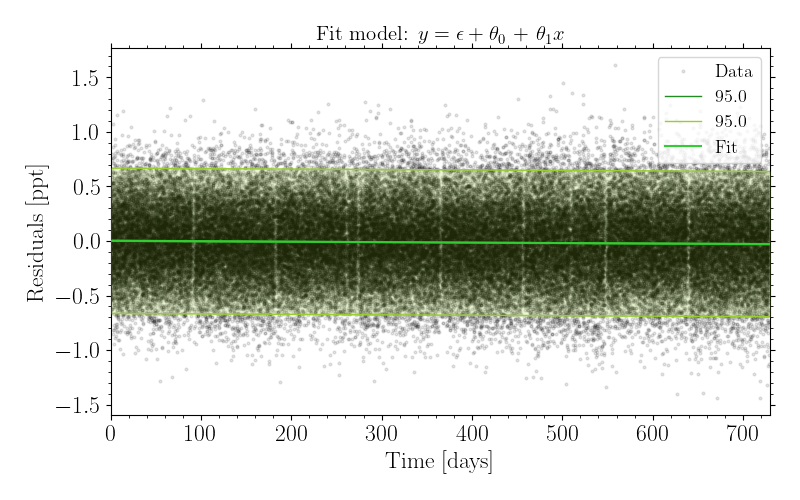

<IPython.core.display.Javascript object>


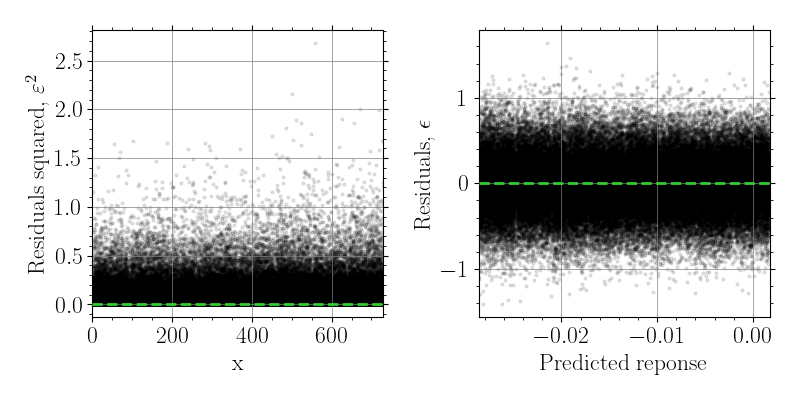

<IPython.core.display.Javascript object>


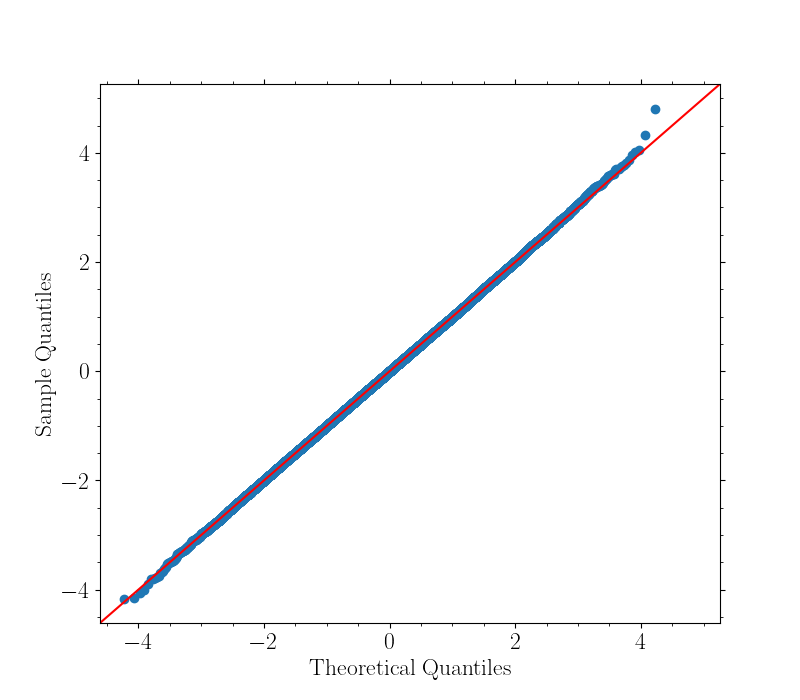

In [17]:
# Plot regression model and residuals
st.plot_modelfit(lc, lsFit, model, lsModel='WLS', theme='g', xlab='Time [days]', ylab='Residuals [ppt]')
st.plot_residuals(lc, lsFit, theme='g')
st.plot_standardized_residuals(lc, lsFit, K=2, reg='x', lsModel='WLS')

In [ ]:
# Load light curve object for the first star only and unpack the data
lcs = LightCurve(f"{idir}/000000001", mode="multi")
lcs.unpack()

---
## Test merging of light curves
---

In [122]:
star = f'{1}'.zfill(9)
idir = f'{path}/simulations/tests/test_hdf5/{star}'
lcs = LightCurve(idir, 'multi')

<IPython.core.display.Javascript object>


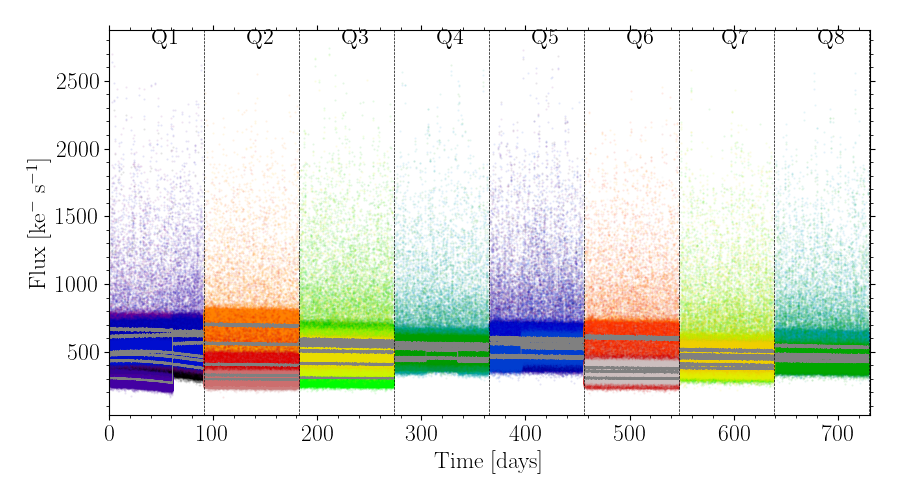

In [134]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

In [125]:
ds = lcs.stat_sim_table(ofile=f'{idir}/lc_{star}.tab', clean=False)
ds.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.24


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,5303012479913170560,134.532937,-60.020178,15.316477,1,1,1,2,1851.767959,800.446693,17.148201,-68.071960,-34.631823,3,0.000211
1,1,5303012479913170560,134.532937,-60.020178,15.316477,1,1,5,2,1851.846302,800.542596,17.148011,-68.070233,-34.633233,3,0.000455
2,1,5303012479913170560,134.532937,-60.020178,15.316477,1,2,1,2,1838.114870,813.420919,17.080649,-67.838423,-34.386068,3,0.000693
3,1,5303012479913170560,134.532937,-60.020178,15.316477,1,2,5,2,1838.193179,813.516759,17.080458,-67.836698,-34.387477,3,0.001294
4,1,5303012479913170560,134.532937,-60.020178,15.316477,1,3,1,2,1847.120518,801.075292,17.138059,-68.060645,-34.548169,3,0.001215


In [603]:
# lc = lcs.merge(suffix='ftr', binsize=0.2, flux_group_mean=True, flux_offset=True, verbose=False)
# fig, ax = lc.plot_oc2(input_model=True, mfilter=1, flux_unit='ppt', figsize=(9,5));

In [604]:
# lc = lcs.merge(suffix='ftr', binsize=0.2, flux_group_mean=True, flux_offset=True, detrend=True, verbose=False)
# fig, ax = lc.plot_oc2(input_model=True, mfilter=1, flux_unit='ppt', figsize=(9,5));

In [46]:
df.mag.iloc[0]

15.316477

In [126]:
lc = lcs.merge(suffix='ftr', verbose=True,
               flux_group_mean=True, 
               clip=False, #df.mag.iloc[0], 
               binsize=0.2, 
               flux_offset=True, 
               flux_err=True, 
               ofile=f'{idir}/lc_{star}.ftr')

[Error]: No files found with suffix ftr!


SystemExit: 

<IPython.core.display.Javascript object>


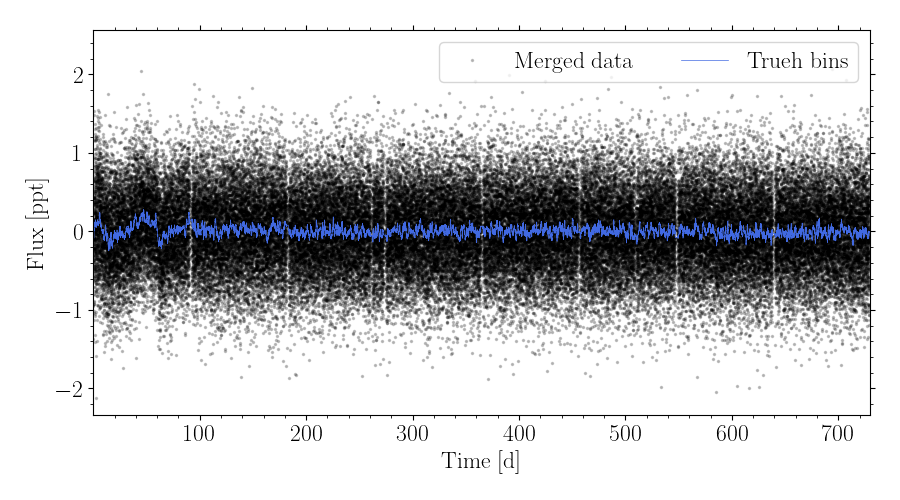

In [83]:
df = lc.gaps(f'{path}/input/instrumentGAP.tab', replace=True)
df = df.dropna()
lc.plot(flux_unit='ppt', median_filter=True);

<IPython.core.display.Javascript object>


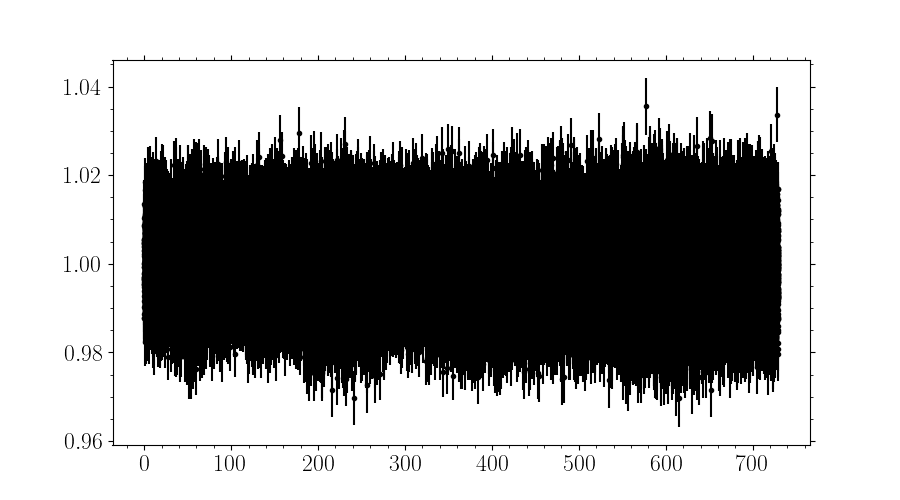

In [59]:
df = lc.data()
plt.figure(figsize=(9,5))
plt.errorbar(df.time/86400, df.flux, yerr=df.flux_err, fmt=".", color='k');

---
## Optimal SNR to extract modes
---

In [468]:
path = '/lhome/nicholas/software/workdir/mocka/snr'

### Single cadence

In [17]:
# dx = ut.plotNoisePeakSNR(cadence=600, quarters=1, N=1000, odir=path)

<IPython.core.display.Javascript object>


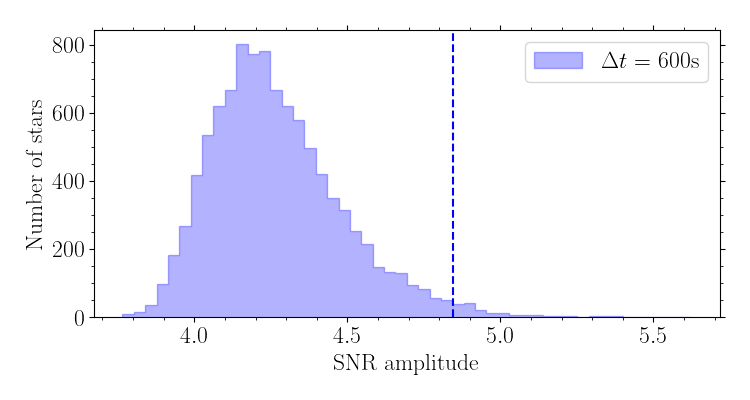

4.845934564977321


In [6]:
fig, ax = ns.plotNoisePeakSNR(path, cadence=600, quarters=8, fap=2, bins=50, figsize=(7.5, 4))

### Multiple cadences

In [28]:
# dx = ns.getNoisePeakSNR(path, quarters=1, N=10)

<IPython.core.display.Javascript object>


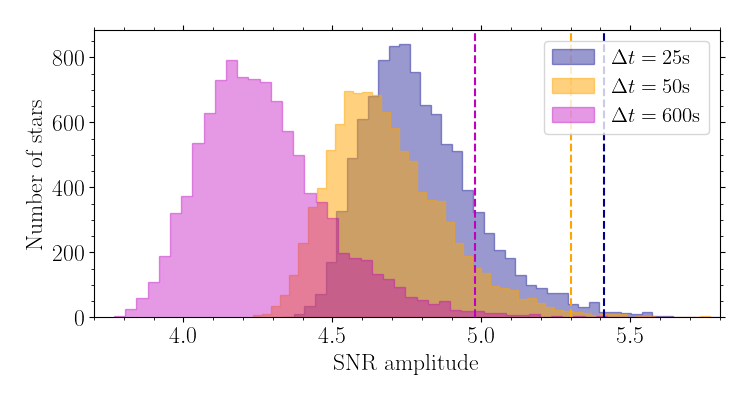

[5.411561511678405, 5.299983634039764, 4.979189659061848]


In [424]:
fig, ax = ns.plotMultiCadenceNoisePeakSNR(path, fap=1, quarters=8, bins=50, show_snr=True, figsize=(7.5, 4));
ax.set_xlim(3.7, 5.8)
fig.savefig(f'{fdir}/OptimalCriterionSNR.png', bbox_inches='tight', dpi=300)

In [469]:
# FAP 10%
q1 = [4.751441961815984, 4.646419784596318, 4.234842108291144]
q2 = [4.863501527270076, 4.758439876832565, 4.340777615792339]
q3 = [4.923252108914589, 4.8116877878757345, 4.425668886924579]
q4 = [4.9669869569925025, 4.862516083165092, 4.476098647285526]
q5 = [4.98942846598262, 4.886290616227712, 4.506715704129862]
q6 = [5.0359025727844555, 4.922331538388892, 4.531516416386822]
q7 = [5.0385894774387046, 4.9395638259157515, 4.552297875935199]
q8 = [5.069942232036235, 4.960187561639028, 4.5862721956125565]
snr10 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap10 = np.ones(len(snr10)) * 10

# FAP 8%
q1 = [4.782985567116099, 4.686789325252121, 4.281951251102321]
q2 = [4.895219481852064, 4.797305009137667, 4.382295813683609]
q3 = [4.960157216344031, 4.8505563734873895, 4.467593862061666]
q4 = [4.996922409199194, 4.899309677901247, 4.514941922304392]
q5 = [5.025912405861571, 4.922160696933164, 4.547942889544587]
q6 = [5.072337956185754, 4.960296669332852, 4.5713168054674975]
q7 = [5.074169685312954, 4.9769127514469345, 4.595362748873413]
q8 = [5.1075052563009615, 4.998480059206906, 4.627299161617078]
snr8 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap8 = np.ones(len(snr8)) * 8

# FAP 6%
q1 = [4.834635101289733, 4.733820911264426, 4.340556948337373]
q2 = [4.941738917271653, 4.839935653201236, 4.436662034249298]
q3 = [5.006117809189146, 4.894677098281585, 4.521218169277734]
q4 = [5.040488659899626, 4.945979289685511, 4.5674777265613935]
q5 = [5.070121790114455, 4.977623777635532, 4.6036870921918345]
q6 = [5.117065787466482, 5.002103348598984, 4.616189688188275]
q7 = [5.1227680986135695, 5.024557753691917, 4.643274441589813]
q8 = [5.154390107953242, 5.045291305022896, 4.675685972431329]
snr6 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap6 = np.ones(len(snr6)) * 6

# FAP 4%
q1 = [4.904358824041422, 4.797333613937177, 4.400652466303963]
q2 = [4.994616951932046, 4.905837966066807, 4.512459886312335]
q3 = [5.068446546378054, 4.959911492153281, 4.592248437697582]
q4 = [5.1024297376411205, 5.007733184246635, 4.639945987395375]
q5 = [5.130284236545739, 5.042588276634922, 4.671854409278135]
q6 = [5.174070117077145, 5.066248464109928, 4.686850529512095]
q7 = [5.179492690650727, 5.0917850622725815, 4.704846278127562]
q8 = [5.225482286947941, 5.105480181672721, 4.740972635060567]
snr4 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap4 = np.ones(len(snr4)) * 4

# FAP 2%
q1 = [5.007283699079344, 4.916244772827773, 4.522354201004243]
q2 = [5.104045478172652, 5.005239801218056, 4.639942383283823]
q3 = [5.172104314263683, 5.05251450603294, 4.711336690410255]
q4 = [5.205691540958301, 5.110952498708383, 4.759260423528731]
q5 = [5.22888123223425, 5.152169889833671, 4.781219551311802]
q6 = [5.275432973156145, 5.178230970269464, 4.788008866569173]
q7 = [5.280368459154169, 5.197812094139507, 4.814891789620325]
q8 = [5.32784380459164, 5.198939187457133, 4.865028808265933]
snr2 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap2 = np.ones(len(snr2)) * 2

# FAP 1%
q1 = [5.099032363235153, 5.06139030759917, 4.469069906810321]
q2 = [5.198279088967152, 5.118046230099662, 4.584393387223682]
q3 = [5.288894196886051, 5.158302762633607, 4.848945837834034]
q4 = [5.294102193742062, 5.232863346891284, 4.858942920527429]
q5 = [5.311611559980742, 5.250664187575773, 4.895351967621635]
q6 = [5.378917955578637, 5.290193573720642, 4.89644868875318]
q7 = [5.374729898899645, 5.308820691115978, 4.931018218429747]
q8 = [5.411561511678405, 5.299983634039764, 4.979189659061848] 
snr1 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap1 = np.ones(len(snr1))

# FAP 0.5%
q1 = [5.2283584483247, 5.139300654559072, 4.7723868180945725]
q2 = [5.309691458335726, 5.243671361003577, 4.861389406587132]
q3 = [5.382026054815434, 5.225276958087124, 4.981278806131673]
q4 = [5.3840281336088545, 5.325152589372627, 4.967849165036273]
q5 = [5.3963747034303005, 5.36272344031128, 5.014040837359414]
q6 = [5.484636980195333, 5.378662604222594, 5.0068987087046795]
q7 = [5.465981832143509, 5.411319280505803, 5.039615870262087]
q8 = [5.5206948785375545, 5.403739350144865, 5.102280214481962]
snr05 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap05 = np.ones(len(snr05)) * 0.5

# FAP 0.1%
q1 = [5.484254692018193, 5.414928279773168, 5.002450189140223]
q2 = [5.561262525313896, 5.513900092145581, 5.065548026369663]
q3 = [5.684501284753266, 5.437315937529918, 5.222092114364679]
q4 = [5.64988078388191, 5.560201329088244, 5.188106000280937]
q5 = [5.699418225306015, 5.734607285629037, 5.2107785792667665]
q6 = [5.649921701407862, 5.5812832757616855, 5.178590146023707]
q7 = [5.62257027641522, 5.650630154633398, 5.302592393831441]
q8 = [5.751536466369376, 5.574414630455777, 5.329219865659611]
snr01 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap01 = np.ones(len(snr01)) * 0.1

# FAP 0.01%
q1 = [5.772338743430787, 6.202782859409507, 5.560570556244156]
q2 = [6.224323506812625, 5.890896661710462, 5.430606388357388]
q3 = [6.1907820711133175, 5.586034730243456, 5.547232681863193]
q4 = [5.95656403869253, 5.896950573705527, 5.52476432406596]
q5 = [6.003399307288348, 5.954491678220407, 6.145481049538461]
q6 = [6.155342528442318, 5.768367312589713, 5.348088751974616]
q7 = [5.906076056502938, 5.924140531057725, 5.748492337539504]
q8 = [6.104093159194544, 5.766214700306862, 5.64730051498106]
snr001 = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
fap001 = np.ones(len(snr001)) * 0.01

N = len(snr10)
quarter = np.arange(1, N+1, 1)
FAP = [fap10, fap8, fap6, fap4, fap2, fap1, fap05, fap01, fap001]
SNR = [snr10, snr8, snr6, snr4, snr2, snr1, snr05, snr01, snr001]

<IPython.core.display.Javascript object>


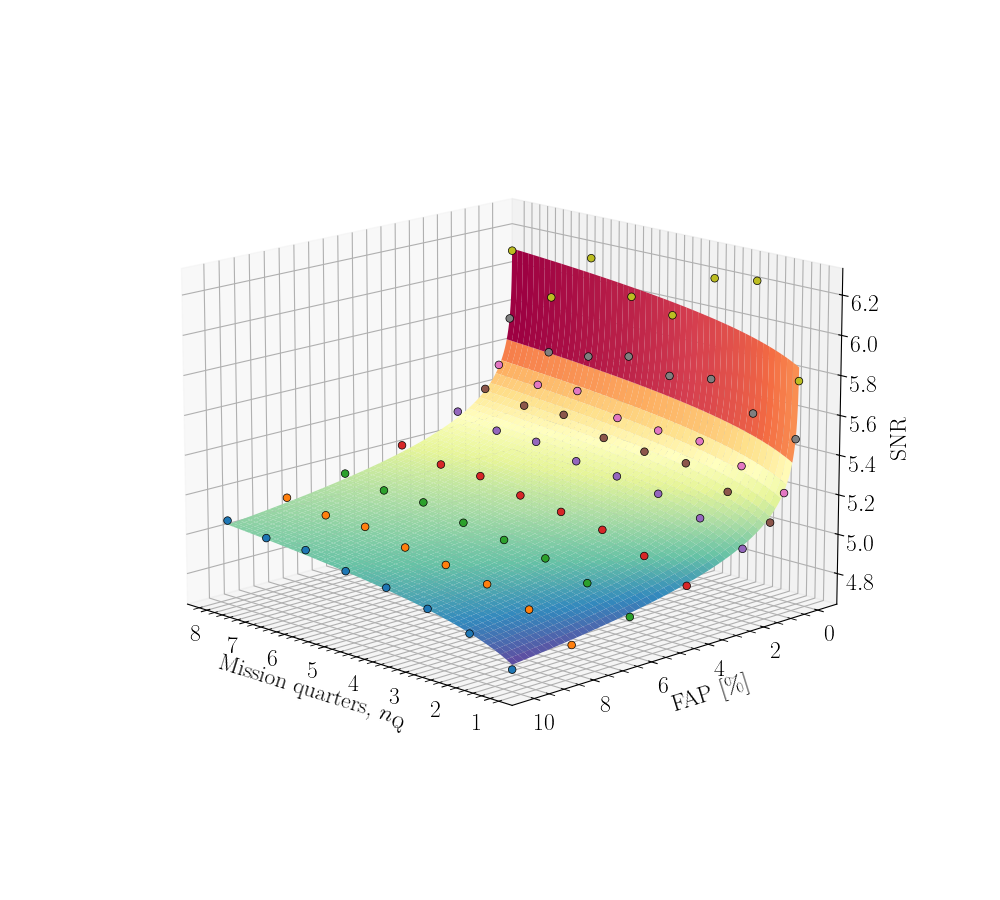

[ 0.13217934 -0.15429918  5.12996448]
[0.01019398 0.00309819 0.01508762]
33.1006013212372


In [470]:
# start plotting
col = 0
fig = plt.figure(figsize=(10,9))
ax = fig.add_subplot(1,1,1, projection='3d', computed_zorder=False)
ax.view_init(elev=15, azim=135)

# Fetch and plot all data points
fap0 = []
snr0 = []
for fap, snr in zip(FAP, SNR):
    ax.scatter3D(quarter, fap, snr[:,col], 'o', ec='k', lw=0.5, s=30, alpha=1, zorder=2)
    fap0.append(fap.tolist())
    snr0.append(snr[:,col].tolist())

# Get 3D array for surface
x = np.tile(quarter, len(np.array(FAP)))
y = np.array(fap0).flatten()
z = np.array(snr0).flatten()
 
# Plot best fit surface
def func(xy, a, b, c):
    x, y = xy
    return  a * np.log(x) + b * np.log(y) + c
popt, pcov = curve_fit(func, (x, y), z)
xx = np.linspace(x.min(), x.max(), 1000) 
yy = np.linspace(y.min(), y.max(), 1000) 
X, Y = np.meshgrid(xx, yy) 
Z = func((X, Y), *popt) 
surf = ax.plot_surface(X, Y, Z, cmap='Spectral_r', alpha=1, zorder=1) 
    
# Labels
ax.set_xlabel(r'Mission quarters, $n_{\rm Q}$', labelpad=10)
ax.set_ylabel('FAP [\%]', labelpad=10)
ax.set_zlabel('SNR', labelpad=10, rotation=90)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.tight_layout(pad=0)

# Save figure and crop with:
# convert OptimalCriterionSurface.png -trim OptimalCriterionSurface.png"
# fig.savefig(f'{fdir}/OptimalCriterionSurface.png', bbox_inches='tight', dpi=300)

# Fit coefficients
print(popt)
print(np.sqrt(np.diag(pcov)))
print(np.linalg.cond(pcov))

In [413]:
# Cadence used in paper
def y(x, y, c=25):
    if   c == 25:  c1, c2, c3 = 0.13217934, -0.15429918, 5.12996448
    elif c == 50:  c1, c2, c3 = 0.10930811, -0.14909435, 5.05757044   
    elif c == 600: c1, c2, c3 = 0.15992845, -0.16496221, 4.62691121
    return c1*np.log(x) + c2*np.log(y) + c3
print(y(8, 0.1, c=25), y(8, 0.1, c=50), y(8, 0.1, c=600))

5.760110682277028 5.628172692536146 5.33931259827982


In [1]:
# # Use correct stellar rotation (slope) from fit
# from scipy.optimize import curve_fit

# def func(x, a, b):
#     return  a * np.log(x) + b #+ a * np.exp(-b * x) +
# Quarter = np.linspace(quarter[0], quarter[-1], 1000)
# popt, pcov = curve_fit(func, quarter, snr10[:,2])
# # Fit coefficients used by varsim
# # print(popt)

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(quarter, snr10[:,2], 'o')
# ax.plot(Quarter, func(Quarter, *popt), 'r-');

In [2]:
# # Use correct stellar rotation (slope) from fit
# from scipy.optimize import curve_fitcp 

# def func(x, a, b):
#     return  a * np.log(x) + b
# FAP = np.linspace(fap10[0], fap001[0], 1000)
# fap = np.array([fap10[0], fap8[0], fap6[0], fap4[0], fap2[0], fap1[0], fap05[0], fap01[0], fap001[0]])
# snr = np.array([snr10[0], snr8[0], snr6[0], snr4[0], snr2[0], snr1[0], snr05[0], snr01[0], snr001[0]])

# popt, pcov = curve_fit(func, fap, snr[:,0])
# # Fit coefficients used by varsim
# print(popt)

# fig, ax = plt.subplots(1, 1, figsize=(8,5))
# ax.plot(fap, snr[:,0], 'o')
# ax.plot(FAP, func(FAP, *popt), 'r-')

---
## Test frequency extraction with STARSHADOW
---

With a PLATOnium conda environment activated, first install software using
```
pip install git+https://github.com/LucIJspeert/star_shadow
```
Open the file needed to compile the `numba` code
```
$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Replace the line:
```
data_dir = script_dir.replace('star_shadow', 'data') 
```
with 
```
data_dir = os.path.join(script_dir, 'data')
```
Check that the `data` folder exists within the directory `$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow`. If not, create this directory and download and place the two files `sim_000_lc.dat` and `mpl_stylesheet.dat` into this folder.

Compile the code with:
```
python $CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
We further implement a small piece of code that records which modes are abvoe a certain SNR during the prewhitening procedure. Then we can compare this to the default procedure of STAR SHADOW.

Now the code can be used.

In [179]:
import star_shadow as ss
path = '/lhome/nicholas/software/workdir/mocka/test_vsc'
filename = f'{path}/varsource/000000001/varsource_001.txt'
df = pd.read_csv(filename, sep=' ', names=['time', 'mag'])

In [45]:
df.time /= 86400.
df['flux'] = ut.fromMagToFlux(df.mag)
df.flux = (df.flux - df.flux.mean())
df['flux_err'] = np.ones_like(df.flux)
df = df.drop(columns=['mag'])
df = df.loc[::24]  # 600s / 25s-> 24 exp
df.to_csv(f'{path}/varsource_600s.dat', sep=' ', index=False, header=False)

In [44]:
plt.figure(figsize=(9,5))
plt.plot(df.time, df.flux, ',', alpha=0.5);

In [ ]:
ss.analyse_lc_from_file(f'{path}/varsource_600s.dat', save_dir=path, stage='freq', overwrite=True, verbose=True)